In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

PHASE 1 : COLLECTE ET EXPLORATION


In [3]:
data=pd.read_csv(r"C:\Users\HP\OneDrive\Projet_Data\Projet 2\Fashion_sales.csv")
data

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3495,Allen Williams,T-Shirts,Oversized T-shirt,NaN,848.79,NaN,0.00,NaN,Mumbai,NaN,2259.00
2496,3496,Jonathan Hill,Shoes,Loafers,4.0,NaN,NaN,0.00,2024-03-10,Hyderabad,B2B,2232.98
2497,3497,Alejandro Cochran,Jackets,Bomber Jacket,NaN,3389.24,1.06,0.00,NaN,Ahmedabad,B2C,1955.31
2498,3498,Angela Adkins,Jeans,Straight Cut,5.0,3844.19,NaN,0.00,24-07-2024,Hyd,NaN,2967.00


In [4]:
data.dtypes

Order_ID              int64
Customer_Name        object
Product_Category     object
Product_Name         object
Units_Sold          float64
Unit_Price          float64
Discount_%          float64
Sales_Amount        float64
Order_Date           object
City                 object
Segment              object
Profit              float64
dtype: object

In [5]:
data.isnull().sum()

Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
Order_Date           606
City                   0
Segment              821
Profit                 0
dtype: int64

Notre dataset est un dataset qui porte sur des commandes commerciales. Nous pouvons observer qu'il contient 2500 commandes (lignes) et que ces dernières sont établies sur la base 12 caractéristiques (colonnes).
Notre dataset est constitué à 50% de variables numériques (Units_Sold , Unit_Price , Discount_% , Sales_Amount , Order_ID , Profit) et 50% de variable catégorielles ( Customer_Name , Product_Category, Product_Name , Order_Date , City , Segment). 
On observe des valeurs manquantes d'une assez grande quantité qui se rapproche de la moitié de la quantité de nos données pour Units_Sold , Unit_Price , Discount_%, Order_Date,Profit.

Pour vérifier la distribution de notre variable cible Profit , nous allons procéder par l'analyse des statistiques descriptives de cette dernière et nous allons la visualiser grâce à un histogramme.
Comme notre variable est une variable quantitative continue , les statistiques que nous allons analyser sont : la moyenne , la médiane , l'écart type et l'intervalle interquartile (IQR), le kurtosis et le skewness.
Pour la visualiser , nous allons utiliser un histogramme car c'est le graphique majoritairement utilisé pour regarder la distribution d'une variable.(phase 2)

In [51]:
#Statistiques descriptives
print("Voici les statistiques descriptives de base :")
print(data["Profit"].describe())
print("-------------------------------------------------------------------")
print("Le skewness est :", data["Profit"].skew())
print("Le kurtosis est :" ,data["Profit"].kurtosis())

Voici les statistiques descriptives de base :
count    2500.000000
mean      981.569032
std      1159.159244
min      -992.610000
25%       -19.670000
50%       947.885000
75%      1993.515000
max      2997.110000
Name: Profit, dtype: float64
-------------------------------------------------------------------
Le skewness est : 0.027370407805566637
Le kurtosis est : -1.1896983735278475


-Notre moyenne est de 981.57 , elle represente la valeur autour de laquelle les données de la variable "Profit" gravite.

-Notre écart-type ici est de 1159.16 , il représente le nombre par lequel nos données s'éloignent de la moyenne donc on peut dire que la plupart des profits se situent entre -178 et 2140.

-Notre mediane est de 947.86 , cela signifie que la valeur centrale du chiffre d'affaire de notre distribution est 0 . L'IQR qui est la différence entre le 3e quartile et le premier ( 75% et 25%) est égale aussi à 947.86  , ce qui signifie que dans la zone des 50% centraux de notre distribution le chiffre d'affaire est aussi égale à 947.86.

-Le skewness est supérieur légèrement supérieur à 0 , notre distribution est donc un peu asymétrique vers la droite .

-Le kurtosis est inférieur à 3 , notre distribution est donc applatie.

PHASE 2 : VISUALISATION

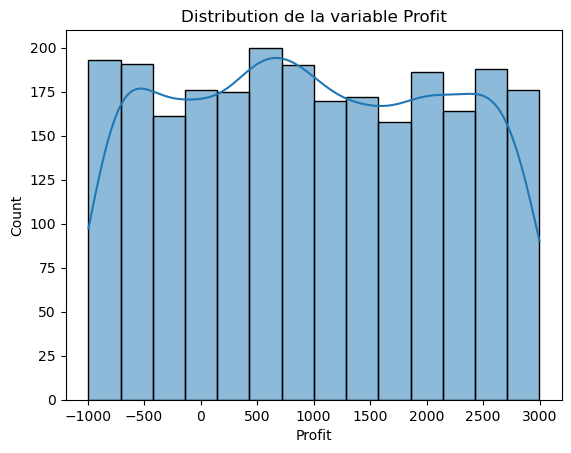

In [52]:
#Histogramme
sn.histplot(data["Profit"] , kde=True )
plt.title("Distribution de la variable Profit")
plt.show()

Notre graphique appuie les réponses apportées par les statistiques descriptives.

Ici , le graphique montre clairement une asymétrie légère au niveau des pâtes de la courbe , on peut voir que la courbe est un peu tiré du côté droit ce qui signifie que la moyenne de notre distribution est tiré légèrement par les valeurs se trouvant du côté droit. Notre graphique n'a qu'une seule bosse alors est unimodale , cela signifie qu'il y a un seul groupe dominant dans notre distribution. Comme confirmé avec la médiane , nous observons que le pic de la courbe se situe au niveau de 0 , il répresente alors vraiment la tendance centrale de notre distribution. Et pour finir , comme nous l'a indiqué le kurtosis , nous pouvons faire que les valeurs de notre distribution sont concentrées.

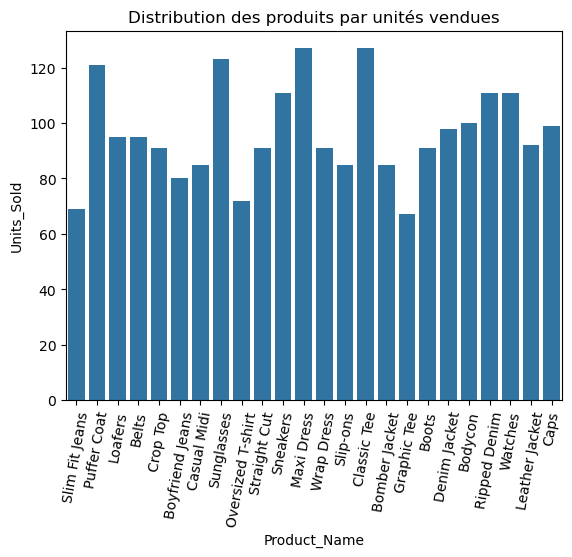

In [8]:
#Diagramme en barre
sn.barplot(data=data , x="Product_Name" , y="Units_Sold", estimator=sum , errorbar=None)
plt.title("Distribution des produits par unités vendues")
plt.xticks(rotation=80)
plt.show()

Par ce graphique , nous avons souhaité nous renseigner sur les 3 produits les plus vendus parmi les commandes passées auprès de l'entreprise. Nous pouvons remarquer que les 3 produits les plus vendus dans les commandes sont : Maxi Dress , Classic Tee et Sunglasses.

Nous avons utilisé un barplot car il est le graphique le plus souvent utilisé lorsque l'on souhaite comparé les valeurs d'une catégorie(variable) par rapport à une autre variable.


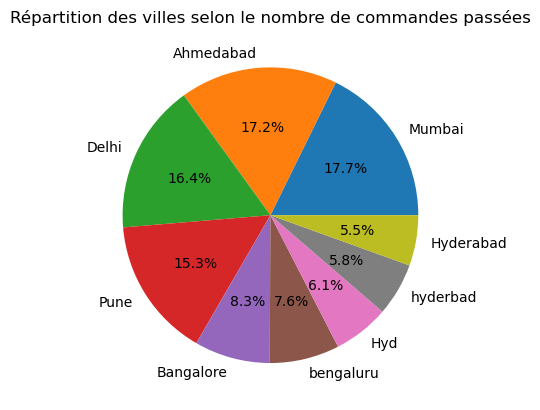

In [9]:
#Diagramme circulaire
comptage=data["City"].value_counts() 
plt.title ("Répartition des villes selon le nombre de commandes passées")
plt.pie(comptage, labels=comptage.index, autopct="%1.1f%%")
plt.show()

Par le biais  de ce graphique , nous avons souhaité voir sur quelle ville nos produits étaient le plus livrés.Avec des écarts très minces , nous avons 4 principales villes : Mumbai , Ahmedabad , Delhi et Pune.

Nous avons choisi un diagramme circulaire pour cette visualisation car il permet facilement de représenter comment les catégories d'une variable catégorielle sont représentées entre elles même.

PHASE 3 : NETTOYAGE ET PREPARATION

Pour la première partie de cette phase , nous allons procéder à la suppression des variables inutiles . Dans le modèle qui nous a été donné , les variables existantes à part la variable cible Sales_Amount sont : Units_Sold , Unit_Price , Discount_% , Segment , Product_Category et City . Les autres variables mis à part celles citées seront supprimées.

In [ ]:
data_clean=data.drop(columns=["Order_ID","Customer_Name","Product_Name","Order_Date","Sales_Amount"])
data_clean.head(12)

,Product_Category,Units_Sold,Unit_Price,Discount_%,Sales_Amount,City,Segment,Profit
0,Jeans,NaN,842.00,0.60,0.00,Delhi,B2C,2137.45
1,Jeans,1.0,NaN,NaN,0.00,Ahmedabad,NaN,1588.15
2,Jackets,1.0,637.82,NaN,0.00,Mumbai,B2B,-158.03
3,Shoes,2.0,2962.27,NaN,0.00,bengaluru,B2B,2296.50
4,Accessories,1.0,2881.07,0.27,2103.18,hyderbad,NaN,63.66
5,T-Shirts,NaN,NaN,NaN,0.00,Mumbai,B2B,1477.73
6,Jeans,1.0,2060.85,NaN,0.00,Ahmedabad,B2B,198.36
7,Dresses,NaN,3669.56,NaN,0.00,Bangalore,B2C,2490.01
8,Accessories,NaN,NaN,NaN,0.00,Ahmedabad,B2C,-886.80
9,T-Shirts,5.0,NaN,NaN,0.00,Bangalore,B2B,-972.73


En voyant tous ses zéros dans notre colonne Sales_Amount , nous aurions pu facilement nous dire qu'il n'y avait pas de problème réelle et que le chiffre n'avait juste pas été calculé mais après avoir regarder de plus près notre base de données , une chose à titiller mon esprit. Nous remarquons que sur les 12 premières lignes la seule commande qui a un chiffre d'affaire est celle qui la quantité vendue , le prix unitaire et le taux de remise. Lorsqu'elle a juste une ou deux de ses variables , le chiffre d'affaire est égale à 0. Nous travaillerons dans la suite de telle sorte à régler ce problème.

Nous allons continuer notre travail par le traitement des valeurs manquantes.

In [11]:
data_clean.isnull().sum()

Product_Category       0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
City                   0
Segment              821
dtype: int64

La colonne Segment ici a 821 données manquantes , nous aurions pu remplacer ces dernières par le mode de la distribution qui aurait été soit B2C ou B2B mais le faire ainsi pourrait fausser les statistiques.En y réfléchissant bien , il se pourrait que ceux qui ont commandé n'ont pas voulu indiqué leur entreprise ou tout simplement que la commande ait été faite par un particulier , alors au lieu de remplacer par le mode , nous allons tout simplement créer une 3e valeur pour segment qui sera "Autre". Cette dernière regroupera les différentes possibilités que nous pouvous avoir pour les valeurs manquantes de cette colonne.

In [12]:
data_clean["Segment"]=data_clean["Segment"].fillna("Autre")

In [13]:
data_clean.head(12)

,Product_Category,Units_Sold,Unit_Price,Discount_%,Sales_Amount,City,Segment
0,Jeans,NaN,842.00,0.60,0.00,Delhi,B2C
1,Jeans,1.0,NaN,NaN,0.00,Ahmedabad,Autre
2,Jackets,1.0,637.82,NaN,0.00,Mumbai,B2B
3,Shoes,2.0,2962.27,NaN,0.00,bengaluru,B2B
4,Accessories,1.0,2881.07,0.27,2103.18,hyderbad,Autre
5,T-Shirts,NaN,NaN,NaN,0.00,Mumbai,B2B
6,Jeans,1.0,2060.85,NaN,0.00,Ahmedabad,B2B
7,Dresses,NaN,3669.56,NaN,0.00,Bangalore,B2C
8,Accessories,NaN,NaN,NaN,0.00,Ahmedabad,B2C
9,T-Shirts,5.0,NaN,NaN,0.00,Bangalore,B2B


Nous pouvous voir que le changement a été fait au sein de la colonne. Nous allons nous attaquer maintenant aux variables Units_Sold et Unit_Price. Pour savoir quoi faire , nous allons premièrement regarder leurs distributions respectives.

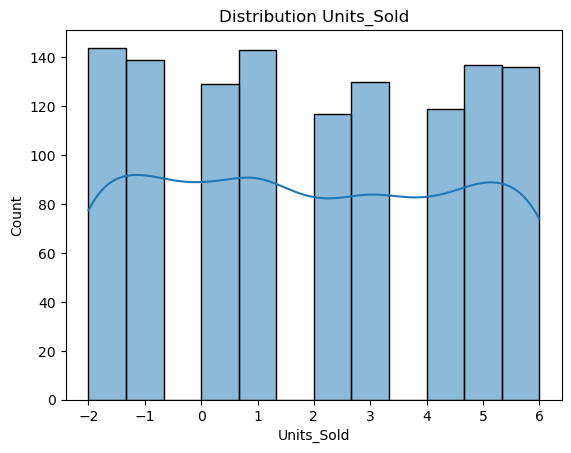

In [14]:
#Distribution Units_Sold
sn.histplot(data_clean["Units_Sold"], kde=True)
plt.title("Distribution Units_Sold")
plt.show()

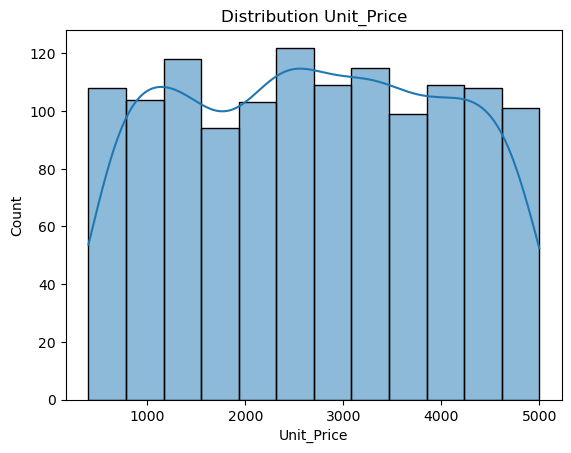

In [15]:
#Distribution Units_Sold
sn.histplot(data_clean["Unit_Price"], kde=True)
plt.title("Distribution Unit_Price")
plt.show()

Notre diagramme ne nous donne pas vraiment d'indication clair quant à la distribution , alors nous allons utiliser les statistiques des variables.

In [16]:
data_clean.describe()

,Units_Sold,Unit_Price,Discount_%,Sales_Amount
count,1194.000000,1290.000000,849.000000,2500.000000
mean,1.940536,2691.715527,0.646466,126.756252
std,2.625680,1320.448967,0.380331,1464.944525
min,-2.000000,400.210000,0.000000,-7518.330000
25%,0.000000,1526.195000,0.300000,0.000000
50%,2.000000,2685.985000,0.650000,0.000000
75%,4.000000,3824.347500,0.980000,0.000000
max,6.000000,4998.910000,1.300000,29180.680000


In [17]:
print("Le skewness de Units_Sold est :", data_clean["Units_Sold"].skew())
print("Le skewness de Unit_Price est :", data_clean["Unit_Price"].skew())
print("---------------------------------------------------------")
print("Le kurtosis de Units_Sold est :", data_clean["Units_Sold"].kurtosis())
print("Le kurtosis de Unit_Price est :", data_clean["Unit_Price"].kurtosis())

Le skewness de Units_Sold est : 0.03750024939920212
Le skewness de Unit_Price est : 0.000379864445391768
---------------------------------------------------------
Le kurtosis de Units_Sold est : -1.2653235400507081
Le kurtosis de Unit_Price est : -1.1744176279632732


Nous pouvons voir grâce aux statistiques que Units_Sold et Unit_Price sont légèrement asymétrique vers la gauche et que leur distribution est applatie. Vu que nous ne sommes pas en présence de valeurs qui tirent excessivement la moyenne vers la droite alors nous allons l'utiliser pour remplacer les valeurs manquantes dans Units_Sold et Unit_Price. Nous utilisons la moyenne car pour une commande de produit , il n'est pas logique que la quantité est été oubliée ou qu'elle soit égale à 0 , tout comme le prix du produit.

In [18]:
data_clean.dtypes

Product_Category     object
Units_Sold          float64
Unit_Price          float64
Discount_%          float64
Sales_Amount        float64
City                 object
Segment              object
dtype: object

Après notre première imputation de données , Units_Sold et Unit_Price qui était des valeurs numeriques sont devenues des valeurs catégorielles. Nous allons changer leurs types , avant de passer à l'imputation des valeurs manquantes.

In [19]:
data_clean["Unit_Price"]=pd.to_numeric(data_clean["Unit_Price"], errors="coerce")
data_clean["Units_Sold"]=pd.to_numeric(data_clean["Units_Sold"], errors="coerce")

In [20]:
data_clean["Unit_Price"]=data_clean["Unit_Price"].fillna(data_clean["Unit_Price"].mean())
data_clean["Units_Sold"]=data_clean["Units_Sold"].fillna(data_clean["Units_Sold"].mean())


In [21]:
data_clean

,Product_Category,Units_Sold,Unit_Price,Discount_%,Sales_Amount,City,Segment
0,Jeans,1.940536,842.000000,0.60,0.00,Delhi,B2C
1,Jeans,1.000000,2691.715527,NaN,0.00,Ahmedabad,Autre
2,Jackets,1.000000,637.820000,NaN,0.00,Mumbai,B2B
3,Shoes,2.000000,2962.270000,NaN,0.00,bengaluru,B2B
4,Accessories,1.000000,2881.070000,0.27,2103.18,hyderbad,Autre
...,...,...,...,...,...,...,...
2495,T-Shirts,1.940536,848.790000,NaN,0.00,Mumbai,Autre
2496,Shoes,4.000000,2691.715527,NaN,0.00,Hyderabad,B2B
2497,Jackets,1.940536,3389.240000,1.06,0.00,Ahmedabad,B2C
2498,Jeans,5.000000,3844.190000,NaN,0.00,Hyd,Autre


In [22]:
data_clean.isnull().sum()

Product_Category       0
Units_Sold             0
Unit_Price             0
Discount_%          1651
Sales_Amount           0
City                   0
Segment                0
dtype: int64

Il ne reste que le variable Discount_% . Pour cette variable nous aurions pu tout simplement supprimer les valeurs maquantes mais après réflexion ces valeurs manquantes ne sont pas un problème. La présence de valeur manquante dans notre colonne , signifie tout simplement qu'il n y a pas eu de remise donc que les valeurs manquantes ici sont égales à 0. Nous allons alors changer ces valeurs par 0 au sein de notre colonne.

In [23]:
data_clean["Discount_%"]=data_clean["Discount_%"].fillna(0)

In [24]:
data_clean.isnull().sum()

Product_Category    0
Units_Sold          0
Unit_Price          0
Discount_%          0
Sales_Amount        0
City                0
Segment             0
dtype: int64

Comme nous pouvons le voir , les données manquantes ont été corrigées et il n y en a plus aucune.

Nous allons ensuite passer à l'encodage des variables catégorielles : City , Segment , Product_category

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
label_encoder=LabelEncoder()

In [27]:
data_clean["City"]=label_encoder.fit_transform(data_clean["City"])
data_clean["Segment"]=label_encoder.fit_transform(data_clean["Segment"])
data_clean["Product_Category"]=label_encoder.fit_transform(data_clean["Product_Category"])

In [28]:
data_clean

,Product_Category,Units_Sold,Unit_Price,Discount_%,Sales_Amount,City,Segment
0,3,1.940536,842.000000,0.60,0.00,2,2
1,3,1.000000,2691.715527,0.00,0.00,0,0
2,2,1.000000,637.820000,0.00,0.00,5,1
3,4,2.000000,2962.270000,0.00,0.00,7,1
4,0,1.000000,2881.070000,0.27,2103.18,8,0
...,...,...,...,...,...,...,...
2495,5,1.940536,848.790000,0.00,0.00,5,0
2496,4,4.000000,2691.715527,0.00,0.00,4,1
2497,2,1.940536,3389.240000,1.06,0.00,0,2
2498,3,5.000000,3844.190000,0.00,0.00,3,0


Nous allons maintenant vérifier la présence de doublons dans notre dataset

In [29]:
nombre=data_clean.duplicated().sum()

In [30]:
print("Il y a", nombre , "doublons dans notre dataset")

Il y a 310 doublons dans notre dataset


Nous allons maintenant les supprimer

In [31]:
data_clean=data_clean.drop_duplicates()

In [32]:
nombre1=data_clean.duplicated().sum()

In [33]:
print("Il y a ",nombre1, " doublons dans notre dataset")

Il y a  0  doublons dans notre dataset


Avant de finir, notre nettoyage par les outliers nous allons régler le problème énoncer plus haut : celui du soucis de calcul pour la variable Sales_Amount. Vu que le problème de valeurs manquantes rencontrés dans Unit_Price , Units_Sold et Discount_% a été réglé , nous allons alors recalculer la colonne.

In [34]:
data_clean["Sales_Amount1"]=data_clean["Unit_Price"] * data_clean["Units_Sold"] - ((data_clean["Unit_Price"] * data_clean["Units_Sold"]) * data_clean["Discount_%"] / 100)

C:\Users\HP\AppData\Local\Temp\ipykernel_18484\2451110279.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean["Sales_Amount1"]=data_clean["Unit_Price"] * data_clean["Units_Sold"] - ((data_clean["Unit_Price"] * data_clean["Units_Sold"]) * data_clean["Discount_%"] / 100)


In [35]:
data_clean

,Product_Category,Units_Sold,Unit_Price,Discount_%,Sales_Amount,City,Segment,Sales_Amount1
0,3,1.940536,842.000000,0.60,0.00,2,2,1624.127735
1,3,1.000000,2691.715527,0.00,0.00,0,0,2691.715527
2,2,1.000000,637.820000,0.00,0.00,5,1,637.820000
3,4,2.000000,2962.270000,0.00,0.00,7,1,5924.540000
4,0,1.000000,2881.070000,0.27,2103.18,8,0,2873.291111
...,...,...,...,...,...,...,...,...
2495,5,1.940536,848.790000,0.00,0.00,5,0,1647.107563
2496,4,4.000000,2691.715527,0.00,0.00,4,1,10766.862109
2497,2,1.940536,3389.240000,1.06,0.00,0,2,6507.226690
2498,3,5.000000,3844.190000,0.00,0.00,3,0,19220.950000


Nous allons supprimer l'ancienne colonne des chiffres d'affaire

In [36]:
data_clean=data_clean.drop(columns=["Sales_Amount"])

In [37]:
data_clean

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment,Sales_Amount1
0,3,1.940536,842.000000,0.60,2,2,1624.127735
1,3,1.000000,2691.715527,0.00,0,0,2691.715527
2,2,1.000000,637.820000,0.00,5,1,637.820000
3,4,2.000000,2962.270000,0.00,7,1,5924.540000
4,0,1.000000,2881.070000,0.27,8,0,2873.291111
...,...,...,...,...,...,...,...
2495,5,1.940536,848.790000,0.00,5,0,1647.107563
2496,4,4.000000,2691.715527,0.00,4,1,10766.862109
2497,2,1.940536,3389.240000,1.06,0,2,6507.226690
2498,3,5.000000,3844.190000,0.00,3,0,19220.950000


Nous avons réglé ce problème avec la variable Sales_Amount , nous allons nous attaquer maintenant aux valeurs manquantes.

Nous allons visualiser les outliers des variables Unit_Price , Units_Sold et Sales_Amount , pour le faire nous allons utiliser des boxplots.

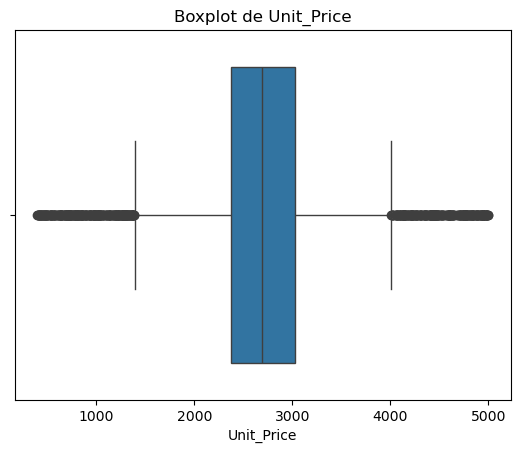

In [38]:
#boxplot Unit_Price
sn.boxplot(x=data_clean["Unit_Price"])
plt.title("Boxplot de Unit_Price")
plt.show()

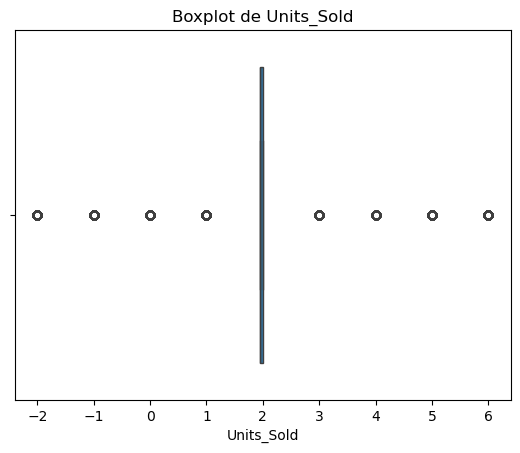

In [39]:
#boxplot Units_Sold
sn.boxplot(x=data_clean["Units_Sold"])
plt.title("Boxplot de Units_Sold")
plt.show()

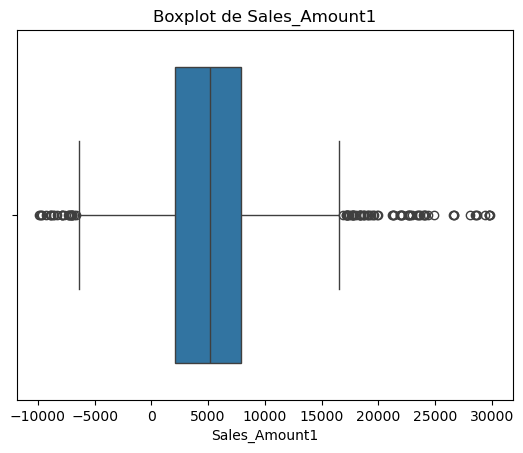

In [40]:
#boxplot Sales_Amount
sn.boxplot(x=data_clean["Sales_Amount1"])
plt.title("Boxplot de Sales_Amount1")
plt.show()

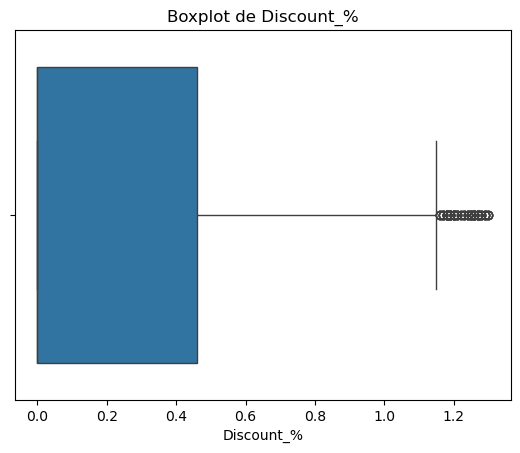

In [41]:
#boxplot Discount_%
sn.boxplot(x=data_clean["Discount_%"])
plt.title("Boxplot de Discount_%")
plt.show()

Après avoir regarder les boxplot et selon le contexte , une grande valeur positive ne représente pas un réel problème car nous pouvons avoir une grande quantité commandé , un taux de remise positif, un prix cher et donc un chiffre d'affaire potentiellement élevé. Nous allons laissé la variable Unit_Price mais nous allons traiter les deux autres valeurs car nous avons remarqué des chiffres d'affaire négatifs ou encore des unités vendues négatifs et il est impossible d'avoir un chiffre d'en avoir alors nous allons les supprimer.

In [42]:
#Nettoyage de Sales_Amount
data_clean=data_clean[data_clean["Sales_Amount1"] > 0] 

In [43]:
#Nettoyage de Unit_Price
data_clean=data_clean[data_clean["Units_Sold"] > 0] 

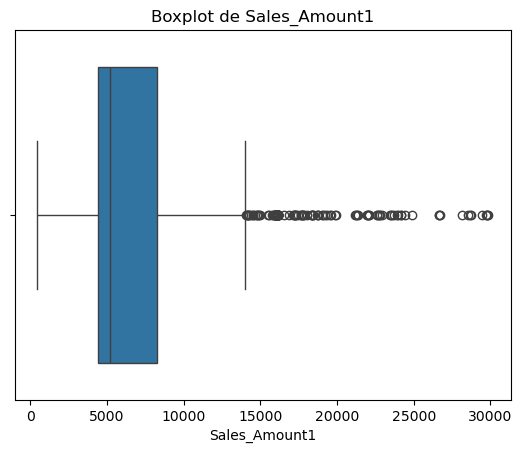

In [44]:
#boxplot Sales_Amount
sn.boxplot(x=data_clean["Sales_Amount1"])
plt.title("Boxplot de Sales_Amount1")
plt.show()

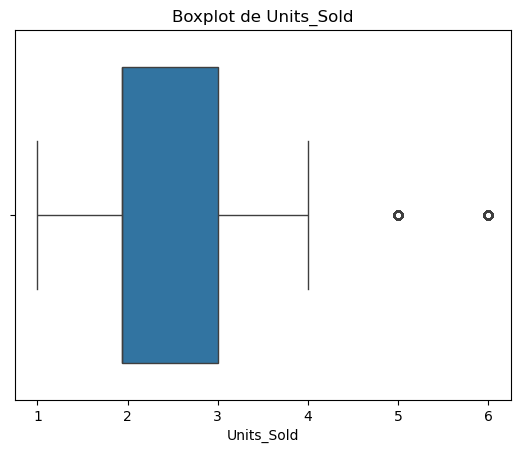

In [45]:
#boxplot Units_Sold
sn.boxplot(x=data_clean["Units_Sold"])
plt.title("Boxplot de Units_Sold")
plt.show()

Comme nous pouvons le voir sur les boxplot , les valeurs inférieures à 0 ont été supprimées pour Units_Sold et Sales_Amount , nous avons officiellement fini le nettoyage de nos données.

PHASE 4 : NORMALISATION ET SEPARATION

Nous allons procéder premièrement à la séparation des features.

In [46]:
X= data_clean.drop(columns=["Sales_Amount1"])
Y=data_clean["Sales_Amount1"]

In [47]:
Y

0        1624.127735
1        2691.715527
2         637.820000
3        5924.540000
4        2873.291111
            ...     
2495     1647.107563
2496    10766.862109
2497     6507.226690
2498    19220.950000
2499     7438.500000
Name: Sales_Amount1, Length: 1795, dtype: float64

Nous allons ensuite diviser en données d'entraînement(train) et données de test(test)

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train , X_test , y_train , y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

PHASE 5 : MODELISATION ET EVALUATION